### EDA for local version

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
import logging, coloredlogs
from datetime import datetime


logger = logging.getLogger(__name__)
coloredlogs.install(
    level='INFO',
    logger=logger,
    fmt='%(asctime)s [%(levelname)s] %(message)s',
    level_styles={'info': {'color': 'green'}, 'error': {'color': 'red', 'bold': True}}
)

def find_project_root(start_path: Path | None = None) -> Path:
    """Ищем папку configs/, поднимаясь вверх по дереву"""
    if start_path is None:
        start_path = Path.cwd()
    current = start_path.resolve()
    while current != current.parent:
        if (current / "configs").exists():
            return current
        current = current.parent
    raise FileNotFoundError("Не удалось найти папку configs/. Запусти ноутбук из корня проекта или создай configs/config.yaml")

PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

if not CONFIG_PATH.exists():
    logger.error("Файл configs/config.yaml не найден")
    raise FileNotFoundError(f"Файл не найден: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

DATA_SOURCE = PROJECT_ROOT / config["paths"]["data_source"]
DATA_PROCESSED = PROJECT_ROOT / config["paths"]["data_processed"]
EDA_PLOTS_DIR = PROJECT_ROOT / config["paths"]["notebooks"] / "eda_plots"
LOGS_DIR = PROJECT_ROOT / config["paths"]["logs"]

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
EDA_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

log_level = getattr(logging, config["logging"]["level"])
log_filename = LOGS_DIR / f"eda_local_{datetime.now():%Y%m%d_%H%M%S}.log"
file_handler = logging.FileHandler(log_filename, encoding="utf-8")
file_handler.setLevel(log_level)
file_formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s')
file_handler.setFormatter(file_formatter)
logger.addHandler(file_handler)

logger.info("Корень проекта определён: %s", PROJECT_ROOT)
logger.info("Данные загружаются из: %s", DATA_SOURCE)
logger.info("Артефакты сохраняются в: %s", DATA_PROCESSED)
logger.info("Логи сохраняются в файл: %s", log_filename)

2026-03-05 00:04:05 [INFO] Корень проекта определён: C:\vs_code_projects\distributed-churn-prediction
2026-03-05 00:04:05 [INFO] Данные загружаются из: C:\vs_code_projects\distributed-churn-prediction\data\source
2026-03-05 00:04:05 [INFO] Артефакты сохраняются в: C:\vs_code_projects\distributed-churn-prediction\data\processed
2026-03-05 00:04:05 [INFO] Логи сохраняются в файл: C:\vs_code_projects\distributed-churn-prediction\logs\eda_local_20260305_000405.log


In [10]:
%%time
TRAIN_PATH = DATA_SOURCE / 'Train.csv'
df = pd.read_csv(TRAIN_PATH)

logger.info("Загружено строк: %s, колонок: %s", f"{df.shape[0]:,}", df.shape[1])

2026-03-05 00:04:13 [INFO] Загружено строк: 2,154,048, колонок: 19


CPU times: total: 7.7 s
Wall time: 7.9 s


In [11]:
logger.info("Информация о датасете (выводится только в консоль):")
df.info()

2026-03-05 00:04:13 [INFO] Информация о датасете (выводится только в консоль):


<class 'pandas.DataFrame'>
RangeIndex: 2154048 entries, 0 to 2154047
Data columns (total 19 columns):
 #   Column          Dtype  
---  ------          -----  
 0   user_id         str    
 1   REGION          str    
 2   TENURE          str    
 3   MONTANT         float64
 4   FREQUENCE_RECH  float64
 5   REVENUE         float64
 6   ARPU_SEGMENT    float64
 7   FREQUENCE       float64
 8   DATA_VOLUME     float64
 9   ON_NET          float64
 10  ORANGE          float64
 11  TIGO            float64
 12  ZONE1           float64
 13  ZONE2           float64
 14  MRG             str    
 15  REGULARITY      int64  
 16  TOP_PACK        str    
 17  FREQ_TOP_PACK   float64
 18  CHURN           int64  
dtypes: float64(12), int64(2), str(5)
memory usage: 459.3 MB


In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
logger.info("Пропуски (топ-10):")
logger.info("\n%s", missing.head(10))
print()

logger.info("Распределение целевой переменной CHURN:")
logger.info("\n%s", df["CHURN"].value_counts(normalize=True))

2026-03-05 00:04:13 [INFO] Пропуски (топ-10):
2026-03-05 00:04:13 [INFO] 
ZONE2            2017224
ZONE1            1984327
TIGO             1290016
DATA_VOLUME      1060433
TOP_PACK          902594
FREQ_TOP_PACK     902594
ORANGE            895248
REGION            849299
ON_NET            786675
MONTANT           756739
dtype: int64
2026-03-05 00:04:13 [INFO] Распределение целевой переменной CHURN:
2026-03-05 00:04:13 [INFO] 
CHURN
0    0.812453
1    0.187547
Name: proportion, dtype: float64


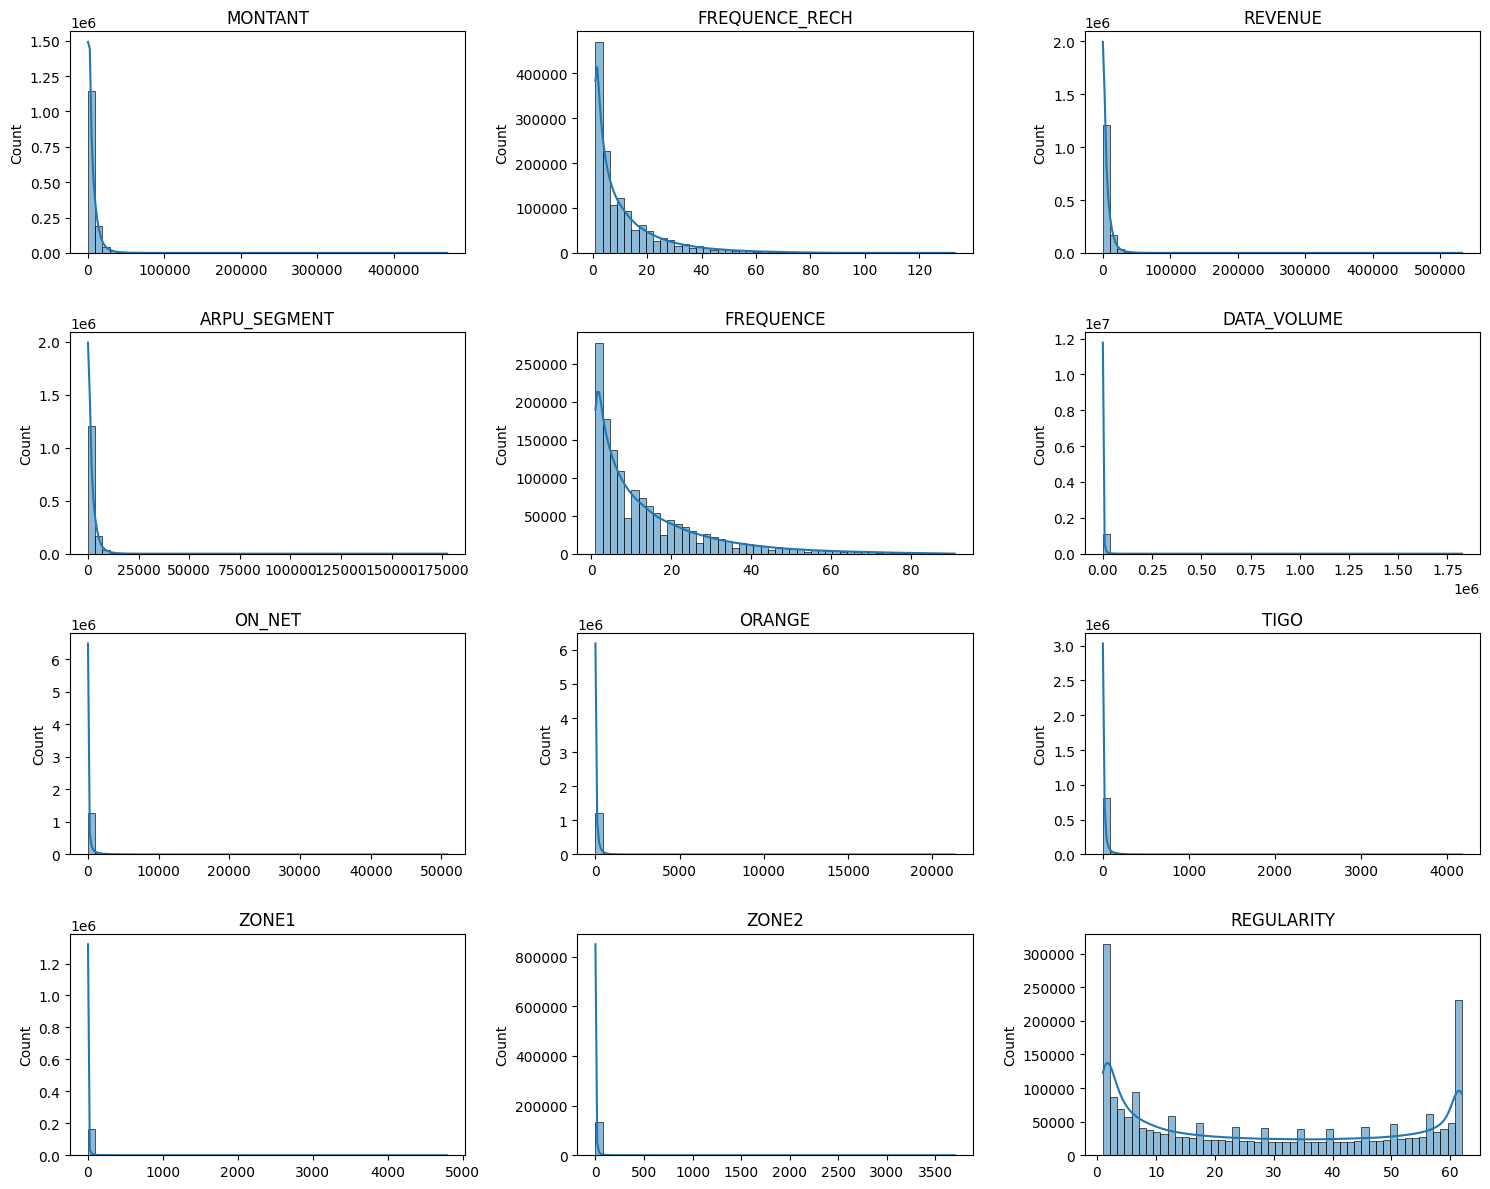

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(['CHURN'], errors='ignore').to_list()

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols[:12], 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.savefig(EDA_PLOTS_DIR / "numerical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
cat_cols = config["preprocessing"]["categorical_columns"]

for col in cat_cols:
    logger.info("Распределение %s (топ-10):", col)
    logger.info(df[col].value_counts(dropna=False).head(10))

2026-03-05 00:05:27 [INFO] Распределение REGION (топ-10):
2026-03-05 00:05:27 [INFO] REGION
NaN            849299
DAKAR          513271
THIES          180052
SAINT-LOUIS    119886
LOUGA           99053
KAOLACK         96986
DIOURBEL        66911
TAMBACOUNDA     55074
KAFFRINE        43963
KOLDA           38743
Name: count, dtype: int64
2026-03-05 00:05:27 [INFO] Распределение TENURE (топ-10):
2026-03-05 00:05:27 [INFO] TENURE
K > 24 month     2043201
I 18-21 month      45278
H 15-18 month      26006
G 12-15 month      14901
J 21-24 month      12725
F 9-12 month        9328
E 6-9 month         1839
D 3-6 month          770
Name: count, dtype: int64
2026-03-05 00:05:27 [INFO] Распределение TOP_PACK (топ-10):
2026-03-05 00:05:27 [INFO] TOP_PACK
NaN                                          902594
All-net 500F=2000F;5d                        317802
On net 200F=Unlimited _call24H               152295
Data:490F=1GB,7d                             115180
Data: 100 F=40MB,24H                    

C:\Users\кс\AppData\Local\Temp\ipykernel_4440\2734394404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")


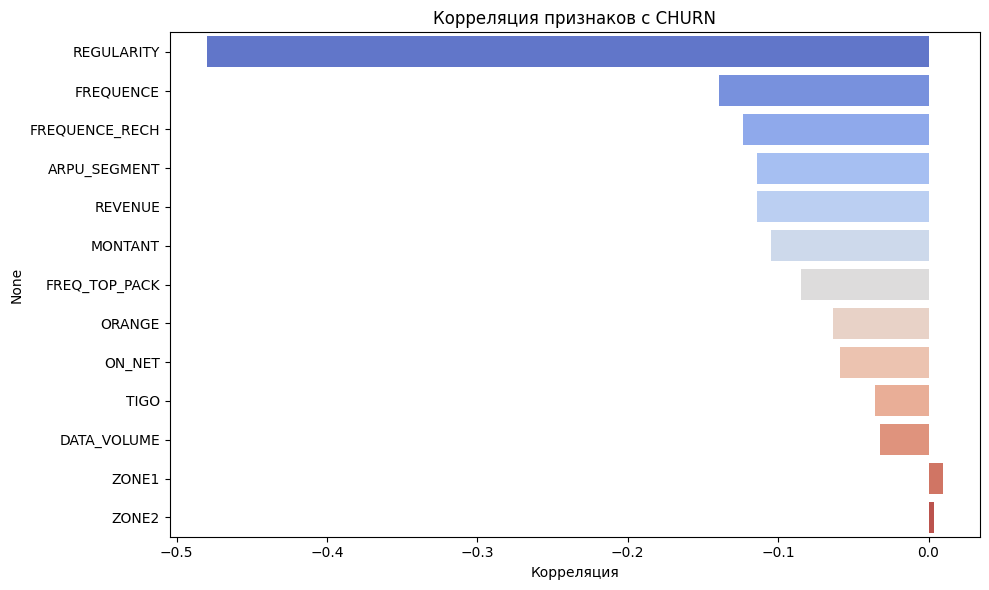

2026-03-05 00:05:29 [INFO] Топ-5 признаков по корреляции с CHURN:
2026-03-05 00:05:29 [INFO] REGULARITY       -0.48
FREQUENCE        -0.14
FREQUENCE_RECH   -0.12
ARPU_SEGMENT     -0.11
REVENUE          -0.11
dtype: float64


In [15]:
corr = df[num_cols].corrwith(df["CHURN"]).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")
plt.title("Корреляция признаков с CHURN")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.savefig(EDA_PLOTS_DIR / "correlation_with_target.png", dpi=300, bbox_inches="tight")
plt.show()

logger.info("Топ-5 признаков по корреляции с CHURN:")
logger.info(corr.head().round(2))

In [16]:
# Базовая статистика
stats_path = DATA_PROCESSED / "eda_summary_stats.csv"
df.describe().to_csv(stats_path)
logger.info("Сохранена статистика: %s", stats_path)

# Список всех колонок
df.dtypes.to_csv(DATA_PROCESSED / "column_types.csv")

logger.info("EDA завершен. Графики сохранены в %s", EDA_PLOTS_DIR)

2026-03-05 00:05:31 [INFO] Сохранена статистика: C:\vs_code_projects\distributed-churn-prediction\data\processed\eda_summary_stats.csv
2026-03-05 00:05:31 [INFO] EDA завершен. Графики сохранены в C:\vs_code_projects\distributed-churn-prediction\notebooks\eda_plots
